In [1]:
# Khai báo Thư viện & Cấu hình
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from collections import Counter

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Nạp dữ liệu & Kỹ thuật đặc trưng
try:
    df = pd.read_csv('dataset_01032026.csv')
    print("Đã nạp file thành công!")
except FileNotFoundError:
    print("Lỗi: Hãy kiểm tra file 'dataset_01032026.csv'.")
    raise

df['structure_density'] = df['num_siblings'] / (df['dom_depth'] + 1)
df['url_complexity'] = df['num_special_chars'] / (df['url_length'] + 1)

cols_to_drop = ['is_ad', 'url', 'dom_depth', 'num_siblings']
X = df.drop(columns=cols_to_drop)
y = df['is_ad']

print(f"Dataset shape: {X.shape}")

Đã nạp file thành công!
Dataset shape: (29342, 9)


In [3]:
# Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Dữ liệu tập Train: {Counter(y_train)}")
print(f"Dữ liệu tập Test:  {Counter(y_test)}")

Dữ liệu tập Train: Counter({0: 20237, 1: 3236})
Dữ liệu tập Test:  Counter({0: 5135, 1: 734})


In [4]:
# Huấn luyện Mô hình
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=15,
    max_features='log2', class_weight='balanced_subsample',
    random_state=42, n_jobs=-1
)

print("Đang huấn luyện mô hình...")
rf.fit(X_train, y_train)
print("Huấn luyện hoàn tất.")

Đang huấn luyện mô hình...
Huấn luyện hoàn tất.


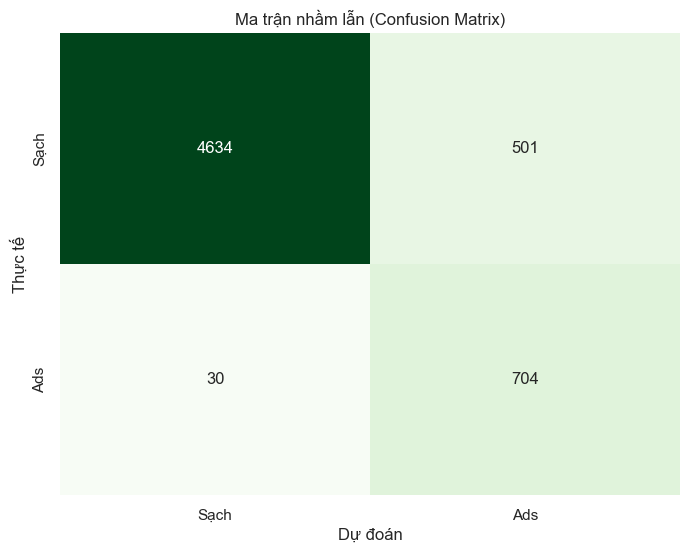

In [5]:
# Hình 1: Confusion Matrix
y_pred = rf.predict(X_test)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sạch', 'Ads'], yticklabels=['Sạch', 'Ads'], cbar=False)
plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")
plt.savefig('evaluation_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

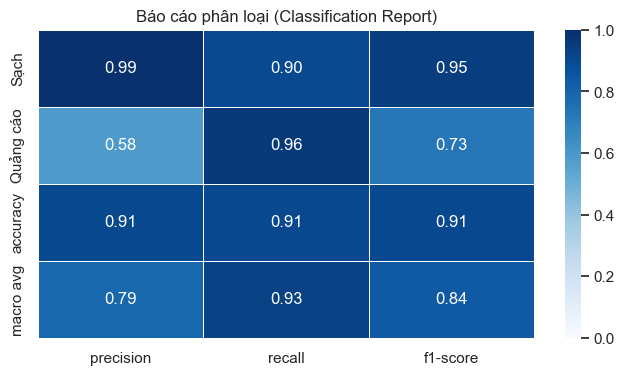

Độ chính xác tổng thể: 0.9095


In [6]:
# Hình 2: Classification Report
report = classification_report(y_test, y_pred,
                                target_names=['Sạch', 'Quảng cáo'],
                                output_dict=True)
report_df = pd.DataFrame(report).transpose().iloc[:-1, :3]

plt.figure(figsize=(8, 4))
sns.heatmap(report_df, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.5)
plt.title("Báo cáo phân loại (Classification Report)")
plt.savefig('evaluation_classification_report.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Độ chính xác tổng thể: {accuracy_score(y_test, y_pred):.4f}")

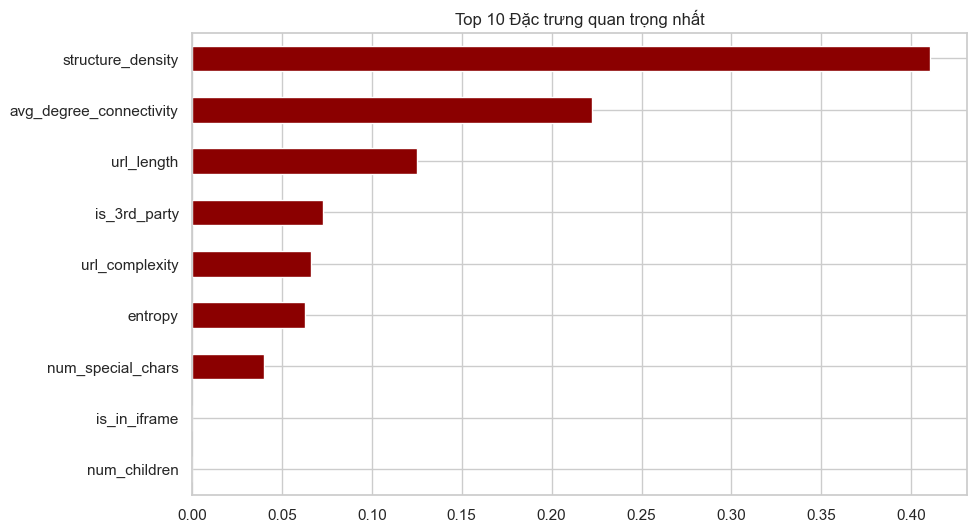

Đã lưu model và danh sách feature!


In [7]:
# Hình 3: Feature Importance & Lưu model
plt.figure(figsize=(10, 6))
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='darkred')
plt.title("Top 10 Đặc trưng quan trọng nhất")
plt.savefig('evaluation_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

storage = {'model': rf, 'features': X.columns.tolist()}
joblib.dump(storage, 'demo2.joblib')
print("Đã lưu model và danh sách feature!")

In [8]:
# Giả lập 1 mẫu quảng cáo thực tế (Banner Dân Trí)
test_ad = pd.DataFrame([{
    'is_3rd_party': 1,
    'url_length': 130,
    'entropy': 4.5,
    'num_special_chars': 14,
    'avg_degree_connectivity': 2,
    'is_in_iframe': 0,
    'structure_density': 0.125,
    'url_complexity': 0.155
}])

for col in X.columns:
    if col not in test_ad.columns:
        test_ad[col] = 0
test_ad = test_ad[X.columns]

prob = rf.predict_proba(test_ad)[0][1]
result = "QUẢNG CÁO" if prob > 0.6 else "SẠCH"

print(f"--- KẾT QUẢ KIỂM TRA ---")
print(f"Xác suất là quảng cáo: {prob*100:.2f}%")
print(f"Kết luận: {result}")

--- KẾT QUẢ KIỂM TRA ---
Xác suất là quảng cáo: 1.16%
Kết luận: SẠCH
